In [1]:
data_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data'  # adjust to your actual path after the move
library(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)
ann <- getAnnotation(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)

Loading required package: minfi

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The fol

In [21]:
tt_114134 <- readRDS("/home/ethan-xiao/food-allergy-biomarkers/data/tt_114134.rds")
tt_189148 <- readRDS("/home/ethan-xiao/food-allergy-biomarkers/data/tt_189148.rds")
bumps_adol <- readRDS("/home/ethan-xiao/food-allergy-biomarkers/data/bumphunter_189148_B250.rds")$table
bumps_infant <- readRDS("/home/ethan-xiao/food-allergy-biomarkers/data/bumphunter_114134.rds")$table

target_probes <- c("cg08469540", "cg25610492")

probe_export <- data.frame(
  probe = target_probes,
  logFC_infant = tt_114134[target_probes, "logFC"],
  p_infant = tt_114134[target_probes, "P.Value"],
  padj_infant = tt_114134[target_probes, "adj.P.Val"],
  logFC_adol = tt_189148[target_probes, "logFC"],
  p_adol = tt_189148[target_probes, "P.Value"],
  padj_adol = tt_189148[target_probes, "adj.P.Val"]
)
write.csv(probe_export, "isg15_probe_stats.csv", row.names = FALSE)

region_export <- rbind(
  cbind(cohort = "infant", subset(bumps_infant, chr == 'chr1' & start < 950000 & end > 948000)),
  cbind(cohort = "adolescent", subset(bumps_adol, chr == 'chr1' & start < 950000 & end > 948000))
)
write.csv(region_export, "isg15_region_stats.csv", row.names = FALSE)

print(probe_export)
print(region_export)

       probe logFC_infant     p_infant padj_infant logFC_adol     p_adol
1 cg08469540   -0.2674742 2.289323e-07  0.03827679 -0.3799635 0.05487312
2 cg25610492   -0.1790107 9.698930e-03  0.38422266 -0.3644607 0.08018272
  padj_adol
1 0.9999969
2 0.9999969
          cohort  chr  start    end      value      area cluster indexStart
16453     infant chr1 948625 948627 -0.2232425 0.4464850      93        281
16454     infant chr1 948814 948814 -0.2133394 0.2133394      93        284
49143 adolescent chr1 948625 948627 -0.3722121 0.7444242      93        281
24    adolescent chr1 948814 948814  0.1734976 0.1734976      93        284
      indexEnd L clusterL     p.value fwer p.valueArea fwerArea
16453      282 2       12 0.017601301    1  0.02787834        1
16454      284 1       12 0.226959960    1  0.25345087        1
49143      282 2       12 0.005893089    1  0.01616685        1
24         284 1       12 0.731086019    1  0.73853713        1


In [23]:
probe_export <- read.csv(file.path(data_dir, "isg15_probe_stats.csv"))
region_export <- read.csv(file.path(data_dir, "isg15_region_stats.csv"))

print(probe_export)
print(region_export)

probe_stats <- data.frame(
  probe        = probe_export$probe,
  chr          = c("chr1", "chr1"),
  pos          = c(948625, 948814),
  logFC_infant = probe_export$logFC_infant,
  padj_infant  = probe_export$padj_infant,
  logFC_adol   = probe_export$logFC_adol,
  padj_adol    = probe_export$padj_adol
)

isg15_region_infant <- subset(region_export, cohort == "infant")
isg15_region_adol   <- subset(region_export, cohort == "adolescent")

print(probe_stats)

       probe logFC_infant     p_infant padj_infant logFC_adol     p_adol
1 cg08469540   -0.2674742 2.289323e-07  0.03827679 -0.3799635 0.05487312
2 cg25610492   -0.1790107 9.698930e-03  0.38422266 -0.3644607 0.08018272
  padj_adol
1 0.9999969
2 0.9999969
      cohort  chr  start    end      value      area cluster indexStart
1     infant chr1 948625 948627 -0.2232425 0.4464850      93        281
2     infant chr1 948814 948814 -0.2133394 0.2133394      93        284
3 adolescent chr1 948625 948627 -0.3722121 0.7444242      93        281
4 adolescent chr1 948814 948814  0.1734976 0.1734976      93        284
  indexEnd L clusterL     p.value fwer p.valueArea fwerArea
1      282 2       12 0.017601301    1  0.02787834        1
2      284 1       12 0.226959960    1  0.25345087        1
3      282 2       12 0.005893089    1  0.01616685        1
4      284 1       12 0.731086019    1  0.73853713        1
       probe  chr    pos logFC_infant padj_infant logFC_adol padj_adol
1 cg08469540 c

In [25]:
rnaseq_results <- read.csv(file.path(data_dir, 'deseq2_results_GSE189149.csv'), row.names = 1)
isg15_rnaseq <- rnaseq_results["9636", c("log2FoldChange", "pvalue", "padj")]
print(isg15_rnaseq)

     log2FoldChange     pvalue      padj
9636     -0.9259212 0.02097726 0.2453401


In [28]:
final_table <- data.frame(
  probe_id             = probe_stats$probe,
  chr                  = probe_stats$chr,
  position_hg19        = probe_stats$pos,
  n_infant             = "59 (39 allergic / 20 control)",
  n_adolescent         = "43 (30 allergic / 13 control)",
  logFC_infant         = probe_stats$logFC_infant,
  padj_infant          = probe_stats$padj_infant,
  logFC_adolescent     = probe_stats$logFC_adol,
  padj_adolescent      = probe_stats$padj_adol,
  region_p_infant      = isg15_region_infant$p.value[1],
  region_fwer_infant   = isg15_region_infant$fwer[1],
  region_p_adolescent  = isg15_region_adol$p.value[1],
  region_fwer_adolescent = isg15_region_adol$fwer[1],
  rnaseq_log2FC        = isg15_rnaseq$log2FoldChange,
  rnaseq_padj          = isg15_rnaseq$padj
)

print(final_table)
write.csv(final_table, file.path(data_dir, 'collaborator_results_table.csv'), row.names = FALSE)

print(final_table)
write.csv(final_table, file.path(data_dir, 'results_table.csv'), row.names = FALSE)

    probe_id  chr position_hg19                      n_infant
1 cg08469540 chr1        948625 59 (39 allergic / 20 control)
2 cg25610492 chr1        948814 59 (39 allergic / 20 control)
                   n_adolescent logFC_infant padj_infant logFC_adolescent
1 43 (30 allergic / 13 control)   -0.2674742  0.03827679       -0.3799635
2 43 (30 allergic / 13 control)   -0.1790107  0.38422266       -0.3644607
  padj_adolescent region_p_infant region_fwer_infant region_p_adolescent
1       0.9999969       0.0176013                  1         0.005893089
2       0.9999969       0.0176013                  1         0.005893089
  region_fwer_adolescent rnaseq_log2FC rnaseq_padj
1                      1    -0.9259212   0.2453401
2                      1    -0.9259212   0.2453401
    probe_id  chr position_hg19                      n_infant
1 cg08469540 chr1        948625 59 (39 allergic / 20 control)
2 cg25610492 chr1        948814 59 (39 allergic / 20 control)
                   n_adolescent lo

pdf 
  2

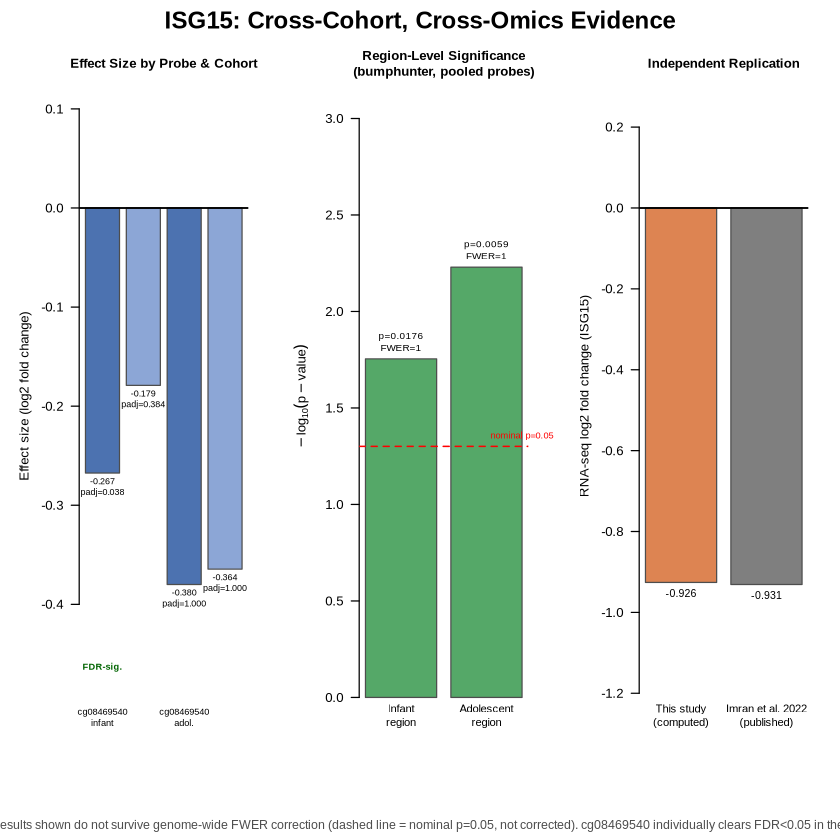

In [35]:
draw_isg15_chart <- function() {
  # Individual probe x cohort bars — no averaging, so no result gets hidden
  bar_effects <- c(probe_stats$logFC_infant, probe_stats$logFC_adol)
  bar_padj    <- c(probe_stats$padj_infant, probe_stats$padj_adol)
  bar_labels  <- c("cg08469540\ninfant", "cg25610492\ninfant",
                    "cg08469540\nadol.", "cg25610492\nadol.")
  bar_colors  <- rep(c("#4C72B0", "#8CA6D6"), 2)  # darker = infant, lighter = adolescent, per probe

  par(mfrow = c(1, 3), mar = c(9, 5, 4, 2), oma = c(0, 0, 2, 0))

  # --- Panel 1: all four probe x cohort results, individually ---
  yrange <- range(c(bar_effects, 0))
  pad <- 0.3 * diff(yrange)
  ylim1 <- yrange + c(-pad, pad)

  bp1 <- barplot(bar_effects, names.arg = bar_labels, col = bar_colors, border = "gray30",
                 main = "Effect Size by Probe & Cohort",
                 ylab = "Effect size (log2 fold change)",
                 ylim = ylim1, cex.names = 0.7, cex.main = 1, las = 1)
  abline(h = 0, lwd = 1.5)
  text(bp1, bar_effects, labels = sprintf("%.3f\npadj=%.3f", bar_effects, bar_padj),
       pos = ifelse(bar_effects < 0, 1, 3), cex = 0.68, xpd = TRUE)
  # Flag the one that actually clears FDR
  fdr_sig <- which(bar_padj < 0.05)
  if (length(fdr_sig) > 0) {
    text(bp1[fdr_sig], ylim1[1] + 0.05*diff(ylim1), "FDR-sig.", col = "darkgreen", font = 2, cex = 0.7, xpd = TRUE)
  }

  # --- Panel 2: region-level (unchanged) ---
  region_p <- c(isg15_region_infant$p.value[1], isg15_region_adol$p.value[1])
  region_fwer <- c(isg15_region_infant$fwer[1], isg15_region_adol$fwer[1])
  neglog10_p <- -log10(region_p)

  bp2 <- barplot(neglog10_p, names.arg = c("Infant\nregion", "Adolescent\nregion"),
                 col = "#55A868", border = "gray30",
                 main = "Region-Level Significance\n(bumphunter, pooled probes)",
                 ylab = expression(-log[10](p-value)),
                 ylim = c(0, max(neglog10_p) * 1.4), cex.names = 0.85, cex.main = 1, las = 1)
  abline(h = -log10(0.05), lty = 2, col = "red", lwd = 1.2)
  text(max(bp2) + 0.5, -log10(0.05), "nominal p=0.05", pos = 3, col = "red", cex = 0.7, xpd = TRUE)
  text(bp2, neglog10_p, labels = sprintf("p=%.4f\nFWER=%.0f", region_p, region_fwer),
       pos = 3, cex = 0.75, xpd = TRUE)

  # --- Panel 3: replication (unchanged) ---
  replication_vals <- c(-0.9259212, -0.931)
  rep_labels <- c("This study\n(computed)", "Imran et al. 2022\n(published)")
  yrange3 <- range(c(replication_vals, 0))
  pad3 <- 0.3 * diff(yrange3)
  ylim3 <- yrange3 + c(-pad3, pad3)

  bp3 <- barplot(replication_vals, names.arg = rep_labels, col = c("#DD8452", "gray50"), border = "gray30",
                 main = "Independent Replication",
                 ylab = "RNA-seq log2 fold change (ISG15)",
                 ylim = ylim3, cex.names = 0.85, cex.main = 1, las = 1)
  abline(h = 0, lwd = 1.5)
  text(bp3, replication_vals, labels = sprintf("%.3f", replication_vals),
       pos = 1, cex = 0.8, xpd = TRUE)

  mtext("ISG15: Cross-Cohort, Cross-Omics Evidence", outer = TRUE, cex = 1.2, font = 2)
  mtext("Region-level results shown do not survive genome-wide FWER correction (dashed line = nominal p=0.05, not corrected). cg08469540 individually clears FDR<0.05 in the infant cohort.",
        side = 1, outer = TRUE, line = -1.5, cex = 0.62, col = "gray30")
}

draw_isg15_chart()

png(file.path(data_dir, 'isg15_crossvalidation_chart.png'), width = 1600, height = 550)
draw_isg15_chart()
dev.off()

In [1]:
library(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)
ann <- getAnnotation(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)

rgs14_probes <- rownames(ann)[ann$chr == "chr5" & ann$pos >= 176797640 & ann$pos <= 176798049]
print(rgs14_probes)  # confirm this isn't empty before continuing

tt_114134 <- readRDS("/home/ethan-xiao/food-allergy-biomarkers/data/tt_114134.rds")
tt_189148 <- readRDS("/home/ethan-xiao/food-allergy-biomarkers/data/tt_189148.rds")
bumps_infant <- readRDS("/home/ethan-xiao/food-allergy-biomarkers/data/bumphunter_114134.rds")$table
bumps_adol   <- readRDS("/home/ethan-xiao/food-allergy-biomarkers/data/bumphunter_189148_B250.rds")$table

rgs14_probe_export <- data.frame(
  probe = rgs14_probes,
  logFC_infant = tt_114134[rgs14_probes, "logFC"],
  padj_infant = tt_114134[rgs14_probes, "adj.P.Val"],
  logFC_adol = tt_189148[rgs14_probes, "logFC"],
  padj_adol = tt_189148[rgs14_probes, "adj.P.Val"]
)
write.csv(rgs14_probe_export, "/home/ethan-xiao/food-allergy-biomarkers/data/rgs14_probe_stats.csv", row.names = FALSE)

rgs14_region_export <- rbind(
  cbind(cohort = "infant", subset(bumps_infant, chr == 'chr5' & start < 176799000 & end > 176797000)),
  cbind(cohort = "adolescent", subset(bumps_adol, chr == 'chr5' & start < 176799000 & end > 176797000))
)
write.csv(rgs14_region_export, "/home/ethan-xiao/food-allergy-biomarkers/data/rgs14_region_stats.csv", row.names = FALSE)

print(rgs14_probe_export)
print(rgs14_region_export)

Loading required package: minfi

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The fol

[1] "cg17509989" "cg16006841" "cg06060754" "cg11598255"
       probe logFC_infant padj_infant logFC_adol padj_adol
1 cg17509989   0.56492432   0.6511559  0.5862384 0.9999969
2 cg16006841   0.33811602   0.7279441  0.3289725 0.9999969
3 cg06060754   0.66781976   0.4319578  0.4008874 0.9999969
4 cg11598255  -0.01138491   0.9730283  0.1651100 0.9999969
          cohort  chr     start       end     value     area cluster indexStart
12923     infant chr5 176797920 176798049 0.5236200 1.570860  306029     602877
38701 adolescent chr5 176797640 176798049 0.3703021 1.481208  306029     602876
      indexEnd L clusterL      p.value fwer p.valueArea fwerArea
12923   602879 3        5 0.0002627308    1 0.001524383        1
38701   602879 4        5 0.0010951768    1 0.002380553        1


In [2]:
rgs14_region_infant <- data.frame(chr="chr5", start=176797920, end=176798049, value=0.5236200, p.value=0.0002627308, fwer=1)
rgs14_region_adol   <- data.frame(chr="chr5", start=176797640, end=176798049, value=0.3703021, p.value=0.0010951768, fwer=1)

In [4]:
export_gene <- function(probes, target_chr, region_start, region_end, name) {
  probe_df <- data.frame(
    probe = probes,
    logFC_infant = tt_114134[probes, "logFC"],
    padj_infant = tt_114134[probes, "adj.P.Val"],
    logFC_adol = tt_189148[probes, "logFC"],
    padj_adol = tt_189148[probes, "adj.P.Val"]
  )

  infant_rows <- bumps_infant[bumps_infant$chr == target_chr &
                               bumps_infant$start < region_end &
                               bumps_infant$end > region_start, ]
  adol_rows <- bumps_adol[bumps_adol$chr == target_chr &
                           bumps_adol$start < region_end &
                           bumps_adol$end > region_start, ]

  region_df <- rbind(
    cbind(cohort = "infant", infant_rows),
    cbind(cohort = "adolescent", adol_rows)
  )

  write.csv(probe_df, sprintf("/home/ethan-xiao/food-allergy-biomarkers/data/%s_probe_stats.csv", name), row.names = FALSE)
  write.csv(region_df, sprintf("/home/ethan-xiao/food-allergy-biomarkers/data/%s_region_stats.csv", name), row.names = FALSE)
  print(probe_df); print(region_df)
}

export_gene(sun1_probes, "chr7", 872130, 872208, "sun1")
export_gene(ninj2_probes, "chr12", 739953, 740338, "ninj2")

       probe logFC_infant padj_infant logFC_adol padj_adol
1 cg21545149    0.2663855   0.8166686   1.225929 0.9999969
2 cg05357209    0.4328019   0.7849535   1.511504 0.9999969
          cohort  chr  start    end     value      area cluster indexStart
14112     infant chr7 872130 872208 0.3495937 0.6991874  329203     653541
42266 adolescent chr7 872130 872293 1.0745129 3.2235386  329203     653541
      indexEnd L clusterL      p.value  fwer  p.valueArea fwerArea
14112   653542 2       11 3.047254e-03 1.000 0.0098047871        1
42266   653543 3       11 2.357281e-05 0.936 0.0003082135        1
       probe logFC_infant padj_infant logFC_adol padj_adol
1 cg14911689    0.6475959   0.5658529  0.5161681 0.9999969
2 cg19692784    0.5863627   0.5974549  0.6743601 0.9999969
3 cg05578102    0.6358131   0.5569111  0.5051166 0.9999969
4 cg01201512    0.5535071   0.6798123  0.2940390 0.9999969
5 cg26654770    1.0064352   0.5886859  0.4792187 0.9999969
         cohort   chr  start    end     val

In [6]:
sun1_probes <- rownames(ann)[ann$chr == "chr7" & ann$pos >= 872130 & ann$pos <= 872208]
ninj2_probes <- rownames(ann)[ann$chr == "chr12" & ann$pos >= 739953 & ann$pos <= 740338]
print(sun1_probes); print(ninj2_probes)

export_gene <- function(probes, chr, region_start, region_end, name) {
  probe_df <- data.frame(
    probe = probes,
    logFC_infant = tt_114134[probes, "logFC"],
    padj_infant = tt_114134[probes, "adj.P.Val"],
    logFC_adol = tt_189148[probes, "logFC"],
    padj_adol = tt_189148[probes, "adj.P.Val"]
  )
  region_df <- rbind(
    cbind(cohort = "infant", subset(bumps_infant, chr == !!chr & start < region_end & end > region_start)),
    cbind(cohort = "adolescent", subset(bumps_adol, chr == !!chr & start < region_end & end > region_start))
  )
  write.csv(probe_df, sprintf("/home/ethan-xiao/food-allergy-biomarkers/data/%s_probe_stats.csv", name), row.names = FALSE)
  write.csv(region_df, sprintf("/home/ethan-xiao/food-allergy-biomarkers/data/%s_region_stats.csv", name), row.names = FALSE)
  print(probe_df); print(region_df)
}

export_gene(sun1_probes, "chr7", 872130, 872208, "sun1")
export_gene(ninj2_probes, "chr12", 739953, 740338, "ninj2")

[1] "cg21545149" "cg05357209"
[1] "cg14911689" "cg19692784" "cg05578102" "cg01201512" "cg26654770"


ERROR: Error in !chr: invalid argument type


In [8]:
build_summary_row <- function(gene_name, file_prefix) {
  probe_df <- read.csv(file.path(data_dir, paste0(file_prefix, "_probe_stats.csv")))
  region_df <- read.csv(file.path(data_dir, paste0(file_prefix, "_region_stats.csv")))

  region_infant <- region_df[region_df$cohort == "infant", ][1, ]
  region_adol <- region_df[region_df$cohort == "adolescent", ][1, ]

  entrez <- gene_entrez[[gene_name]]
  rna_row <- if (entrez %in% rownames(rnaseq_results)) rnaseq_results[entrez, ] else NULL

  data.frame(
    gene                = gene_name,
    methylation_value_infant = region_infant$value,
    methylation_value_adol   = region_adol$value,
    region_p_infant     = region_infant$p.value,
    region_p_adol       = region_adol$p.value,
    best_probe_padj_infant = min(probe_df$padj_infant, na.rm = TRUE),
    best_probe_padj_adol   = min(probe_df$padj_adol, na.rm = TRUE),
    rnaseq_log2FC       = if (!is.null(rna_row)) rna_row$log2FoldChange else NA,
    rnaseq_padj         = if (!is.null(rna_row)) rna_row$padj else NA,
    region_fwer_infant  = region_infant$fwer,
    region_fwer_adol    = region_adol$fwer
  )
}

summary_table <- do.call(rbind, list(
  build_summary_row("ISG15", "isg15"),
  build_summary_row("RGS14", "rgs14"),
  build_summary_row("SUN1", "sun1"),
  build_summary_row("NINJ2", "ninj2")
))

print(summary_table)
write.csv(summary_table, file.path(data_dir, "summary_results_table.csv"), row.names = FALSE)

   gene methylation_value_infant methylation_value_adol region_p_infant
1 ISG15               -0.2232425             -0.3722121    1.760130e-02
2 RGS14                0.5236200              0.3703021    2.627308e-04
3  SUN1                0.3495937              1.0745129    3.047254e-03
4 NINJ2                0.6859428              0.4937805    1.904723e-05
  region_p_adol best_probe_padj_infant best_probe_padj_adol rnaseq_log2FC
1  5.893089e-03             0.03827679            0.9999969    -0.9259212
2  1.095177e-03             0.43195781            0.9999969     0.2475245
3  2.357281e-05             0.78495350            0.9999969     0.1481475
4  2.455783e-04             0.55691107            0.9999969     0.1966325
  rnaseq_padj region_fwer_infant region_fwer_adol
1   0.2453401              1.000            1.000
2   0.1021464              1.000            1.000
3   0.1613000              1.000            0.936
4   0.4473577              0.408            1.000


In [9]:
build_summary_row <- function(gene_name, file_prefix) {
  probe_df <- read.csv(file.path(data_dir, paste0(file_prefix, "_probe_stats.csv")))
  region_df <- read.csv(file.path(data_dir, paste0(file_prefix, "_region_stats.csv")))

  region_infant <- region_df[region_df$cohort == "infant", ][1, ]
  region_adol <- region_df[region_df$cohort == "adolescent", ][1, ]

  entrez <- gene_entrez[[gene_name]]
  rna_row <- if (entrez %in% rownames(rnaseq_results)) rnaseq_results[entrez, ] else NULL
  rnaseq_p <- if (!is.null(rna_row)) rna_row$pvalue else NA

  p_infant <- region_infant$p.value
  p_adol <- region_adol$p.value
  p_rnaseq <- rnaseq_p

  # --- Fisher's method (unweighted, matches notebook 10's combined_p_full) ---
  fisher_p <- if (!is.na(p_rnaseq)) {
    1 - pchisq(-2 * (log(p_infant) + log(p_adol) + log(p_rnaseq)), df = 6)
  } else {
    1 - pchisq(-2 * (log(p_infant) + log(p_adol)), df = 4)
  }

  # --- Stouffer's method (weighted by sqrt(n) per source) ---
  n_infant <- 59; n_adol <- 43; n_rnaseq <- 48
  z_infant <- qnorm(1 - p_infant); z_adol <- qnorm(1 - p_adol)
  z_rnaseq <- if (!is.na(p_rnaseq)) qnorm(1 - p_rnaseq) else NA

  if (!is.na(z_rnaseq)) {
    weights <- sqrt(c(n_infant, n_adol, n_rnaseq))
    z_values <- c(z_infant, z_adol, z_rnaseq)
  } else {
    weights <- sqrt(c(n_infant, n_adol))
    z_values <- c(z_infant, z_adol)
  }
  stouffer_z <- sum(weights * z_values) / sqrt(sum(weights^2))
  stouffer_p <- 1 - pnorm(stouffer_z)

  data.frame(
    gene = gene_name,
    methylation_value_infant = region_infant$value,
    methylation_value_adol = region_adol$value,
    region_p_infant = p_infant,
    region_p_adol = p_adol,
    best_probe_padj_infant = min(probe_df$padj_infant, na.rm = TRUE),
    best_probe_padj_adol = min(probe_df$padj_adol, na.rm = TRUE),
    rnaseq_log2FC = if (!is.null(rna_row)) rna_row$log2FoldChange else NA,
    rnaseq_padj = if (!is.null(rna_row)) rna_row$padj else NA,
    region_fwer_infant = region_infant$fwer,
    region_fwer_adol = region_adol$fwer,
    combined_p_fisher = fisher_p,
    combined_p_stouffer = stouffer_p
  )
}

summary_table <- do.call(rbind, list(
  build_summary_row("ISG15", "isg15"),
  build_summary_row("RGS14", "rgs14"),
  build_summary_row("SUN1", "sun1"),
  build_summary_row("NINJ2", "ninj2")
))

summary_table <- summary_table[order(summary_table$combined_p_fisher), ]
print(summary_table)
write.csv(summary_table, file.path(data_dir, "summary_results_table.csv"), row.names = FALSE)

   gene methylation_value_infant methylation_value_adol region_p_infant
2 RGS14                0.5236200              0.3703021    2.627308e-04
3  SUN1                0.3495937              1.0745129    3.047254e-03
4 NINJ2                0.6859428              0.4937805    1.904723e-05
1 ISG15               -0.2232425             -0.3722121    1.760130e-02
  region_p_adol best_probe_padj_infant best_probe_padj_adol rnaseq_log2FC
2  1.095177e-03             0.43195781            0.9999969     0.2475245
3  2.357281e-05             0.78495350            0.9999969     0.1481475
4  2.455783e-04             0.55691107            0.9999969     0.1966325
1  5.893089e-03             0.03827679            0.9999969    -0.9259212
  rnaseq_padj region_fwer_infant region_fwer_adol combined_p_fisher
2   0.1021464              1.000            1.000      5.316768e-08
3   0.1613000              1.000            0.936      9.807738e-08
4   0.4473577              0.408            1.000      1.344528e-0

In [18]:
evidence_type <- c(
  RGS14 = "Strongest internal evidence; unrelated-disease biology (IBD, lymphocyte activation) (GWAS study info as well)",
  SUN1  = "Internal evidence plus some immune biology literature",
  NINJ2 = "Internal evidence plus some immune biology literature",
  ISG15 = "Externally replicated (Imran et al. 2022), so primary reported finding"
)

pretty_table <- summary_table
pretty_table$evidence_type <- evidence_type[pretty_table$gene]

pretty_table_display <- data.frame(
  Gene = pretty_table$gene,
  `Methyl_Infant` = round(pretty_table$methylation_value_infant, 3),
  `Methyl_Adol` = round(pretty_table$methylation_value_adol, 3),
  `RegionP_Infant` = formatC(pretty_table$region_p_infant, format = "e", digits = 2),
  `RegionP_Adol` = formatC(pretty_table$region_p_adol, format = "e", digits = 2),
  `BestProbePadj_Infant` = round(pretty_table$best_probe_padj_infant, 3),
  `BestProbePadj_Adol` = round(pretty_table$best_probe_padj_adol, 3),
  `RNAseq_log2FC` = round(pretty_table$rnaseq_log2FC, 3),
  `RNAseq_padj` = round(pretty_table$rnaseq_padj, 3),
  `FWER_Infant` = round(pretty_table$region_fwer_infant, 3),
  `FWER_Adol` = round(pretty_table$region_fwer_adol, 3),
  `CombinedP_Fisher` = formatC(pretty_table$combined_p_fisher, format = "e", digits = 2),
  `CombinedP_Stouffer` = formatC(pretty_table$combined_p_stouffer, format = "e", digits = 2),
  `Evidence_Type` = pretty_table$evidence_type,
  check.names = FALSE
)

print(pretty_table_display, row.names = FALSE)

write.csv(pretty_table, file.path(data_dir, "summary_results_table.csv"), row.names = FALSE)
write.csv(pretty_table_display, file.path(data_dir, "summary_results_table_formatted.csv"), row.names = FALSE)

  Gene Methyl_Infant Methyl_Adol RegionP_Infant RegionP_Adol
 RGS14         0.524       0.370       2.63e-04     1.10e-03
  SUN1         0.350       1.075       3.05e-03     2.36e-05
 NINJ2         0.686       0.494       1.90e-05     2.46e-04
 ISG15        -0.223      -0.372       1.76e-02     5.89e-03
 BestProbePadj_Infant BestProbePadj_Adol RNAseq_log2FC RNAseq_padj FWER_Infant
                0.432                  1         0.248       0.102       1.000
                0.785                  1         0.148       0.161       1.000
                0.557                  1         0.197       0.447       0.408
                0.038                  1        -0.926       0.245       1.000
 FWER_Adol CombinedP_Fisher CombinedP_Stouffer
     1.000         5.32e-08           9.14e-09
     0.936         9.81e-08           4.53e-08
     1.000         1.34e-07           1.46e-07
     1.000         2.15e-04           6.68e-05
                                                                 